Импорт необходимых библиотек

In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import json
import csv

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


Вспомогательные функции (метрики и графики)

In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "", save_path: str | None = None) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="train_loss")
    axes[0].plot(epochs, history["val_loss"], label="val_loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title((title + " (loss)") if title else "loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], label="train_acc")
    axes[1].plot(epochs, history["val_acc"], label="val_acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title((title + " (accuracy)") if title else "accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()


def append_run_to_csv(row: dict, csv_path="artifacts/runs.csv"):
    file_exists = os.path.exists(csv_path)
    file_is_empty = (not file_exists) or (os.path.getsize(csv_path) == 0)

    fieldnames = [
        "experiment_id",
        "dataset",
        "seed",
        "model_summary",
        "optimizer",
        "lr",
        "momentum",
        "weight_decay",
        "epochs_trained",
        "best_val_accuracy",
        "best_val_loss",
    ]

    with open(csv_path, mode="a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        if file_is_empty:
            writer.writeheader()

        writer.writerow(row)

def make_model_summary(hidden_dims, activation, dropout_p, use_batchnorm):
    return (
        f"hidden={hidden_dims}; "
        f"activation={activation}; "
        f"dropout={dropout_p}; "
        f"batchnorm={use_batchnorm}"
    )

Разбиение train/val и DataLoader

In [4]:
# Трансформации: ToTensor и Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, download=True, transform=transform, split = "balanced"
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, download=True, transform=transform, split = "balanced"
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800
x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


Смотрим на примеры

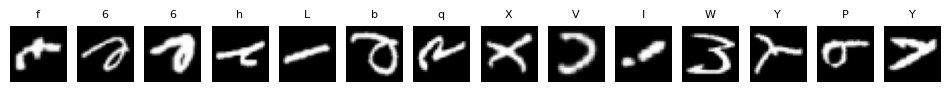

In [5]:
def show_images(loader, n: int = 14) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=14)

Модель: MLP

In [6]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers: list[nn.Module] = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


Цикл обучения: train/eval + no_grad

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches
     

EarlyStopping

In [8]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

Обучение: базовый MLP (baseline)

In [9]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.1387, acc=0.6640 | val loss=0.7426, acc=0.7710
epoch 02/20 | train loss=0.6642, acc=0.7863 | val loss=0.6354, acc=0.7949
epoch 03/20 | train loss=0.5651, acc=0.8115 | val loss=0.5622, acc=0.8197
epoch 04/20 | train loss=0.5115, acc=0.8261 | val loss=0.5708, acc=0.8185
epoch 05/20 | train loss=0.4762, acc=0.8357 | val loss=0.5183, acc=0.8367
epoch 06/20 | train loss=0.4469, acc=0.8435 | val loss=0.5263, acc=0.8309
epoch 07/20 | train loss=0.4259, acc=0.8491 | val loss=0.5273, acc=0.8336
epoch 08/20 | train loss=0.4099, acc=0.8530 | val loss=0.5290, acc=0.8301
epoch 09/20 | train loss=0.3971, acc=0.8573 | val loss=0.5189, acc=0.8340
epoch 10/20 | train loss=0.3796, acc=0.8616 | val loss=0.5464, acc=0.8303
epoch 11/20 | train loss=0.3691, acc=0.8644 | val loss=0.5342, acc=0.8318
epoch 12/20 | train loss=0.3585, acc=0.8672 | val loss=0.5333, acc=0.8380
epoch 13/20 | train loss=0.3498, acc=0.8696 | val loss=0.5236, acc=0.8388
epoch 14/20 | train loss=0.3410, acc=0

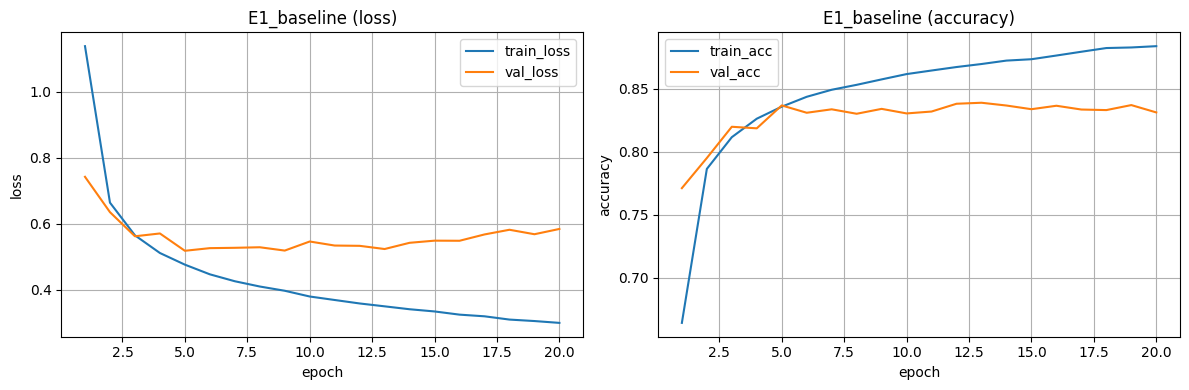

In [10]:
# Baseline: без Dropout и BatchNorm
# Общие настройки
set_seed(42)

NUM_CLASSES = len(class_names)
HIDDEN_DIMS = (256, 128)
LR = 1e-3
EPOCHS = 20

criterion = nn.CrossEntropyLoss()

# E1 — baseline: без Dropout и без BatchNorm
e1_model = MLP(
    hidden_dims=HIDDEN_DIMS,
    num_classes=NUM_CLASSES,
    dropout_p=0.0,
    use_batchnorm=False,
).to(device)

optimizer_e1 = optim.Adam(e1_model.parameters(), lr=LR)

history_e1 = fit(
    model=e1_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e1,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    early_stopping=None,
)

print("\nE1: baseline")

best_val_acc_e1 = max(history_e1["val_acc"])
best_val_loss_e1 = min(history_e1["val_loss"])
epochs_trained_e1 = len(history_e1["train_loss"])

print("best val_acc:", best_val_acc_e1)
print("best val_loss:", best_val_loss_e1)

plot_history(history_e1, title="E1_baseline")

DATASET_NAME = "EMNIST"

SEED = 42
HIDDEN_DIMS = (256, 128)
ACTIVATION = "relu"

LR = 1e-3
WEIGHT_DECAY = 0.0
EPOCHS = 20

append_run_to_csv({
    "experiment_id": "E1",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": make_model_summary(HIDDEN_DIMS, ACTIVATION, 0.0, False),
    "optimizer": "Adam",
    "lr": LR,
    "momentum": 0,
    "weight_decay": WEIGHT_DECAY,
    "epochs_trained": epochs_trained_e1,
    "best_val_accuracy": best_val_acc_e1,
    "best_val_loss": best_val_loss_e1,
})

Эксперимент 1: Dropout

epoch 01/20 | train loss=1.5232, acc=0.5543 | val loss=0.8609, acc=0.7391
epoch 02/20 | train loss=1.0391, acc=0.6803 | val loss=0.7256, acc=0.7705
epoch 03/20 | train loss=0.9350, acc=0.7054 | val loss=0.6674, acc=0.7854
epoch 04/20 | train loss=0.8869, acc=0.7198 | val loss=0.6311, acc=0.7987
epoch 05/20 | train loss=0.8576, acc=0.7272 | val loss=0.6076, acc=0.8065
epoch 06/20 | train loss=0.8321, acc=0.7335 | val loss=0.6092, acc=0.8038
epoch 07/20 | train loss=0.8188, acc=0.7369 | val loss=0.5892, acc=0.8099
epoch 08/20 | train loss=0.8089, acc=0.7418 | val loss=0.5897, acc=0.8079
epoch 09/20 | train loss=0.7915, acc=0.7455 | val loss=0.5587, acc=0.8188
epoch 10/20 | train loss=0.7818, acc=0.7473 | val loss=0.5662, acc=0.8166
epoch 11/20 | train loss=0.7781, acc=0.7482 | val loss=0.5535, acc=0.8220
epoch 12/20 | train loss=0.7694, acc=0.7511 | val loss=0.5585, acc=0.8181
epoch 13/20 | train loss=0.7608, acc=0.7530 | val loss=0.5473, acc=0.8254
epoch 14/20 | train loss=0.7562, acc=0

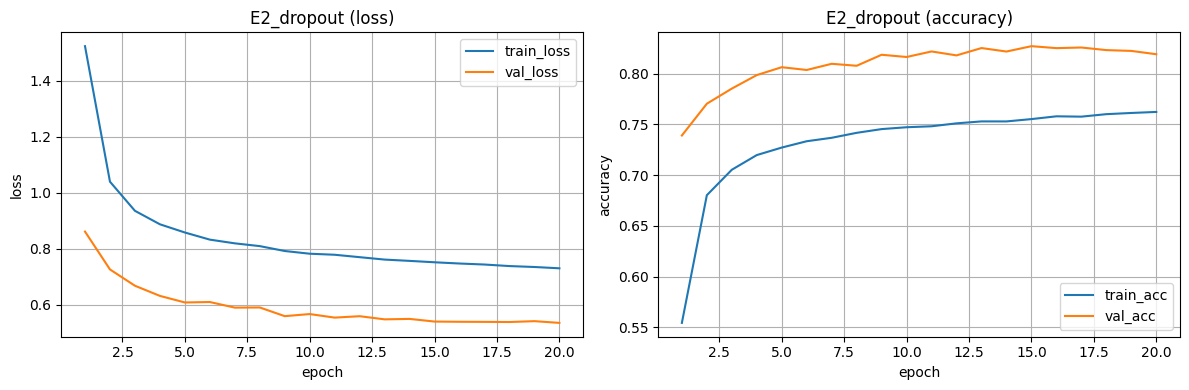

In [11]:
# E2 — Dropout: как E1, но с Dropout

set_seed(42)

e2_model = MLP(
    hidden_dims=HIDDEN_DIMS,
    num_classes=NUM_CLASSES,
    dropout_p=0.3,
    use_batchnorm=False,
).to(device)

optimizer_e2 = optim.Adam(e2_model.parameters(), lr=LR)

history_e2 = fit(
    model=e2_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e2,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    early_stopping=None,
)

best_val_acc_e2 = max(history_e2["val_acc"])
best_val_loss_e2 = min(history_e2["val_loss"])
epochs_trained_e2 = len(history_e2["train_loss"])

print("best val_acc:", best_val_acc_e2)
print("best val_loss:", best_val_loss_e2)

plot_history(history_e2, title="E2_dropout")

append_run_to_csv({
    "experiment_id": "E2",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": make_model_summary(HIDDEN_DIMS, ACTIVATION, 0.3, False),
    "optimizer": "Adam",
    "lr": LR,
    "momentum": 0,
    "weight_decay": WEIGHT_DECAY,
    "epochs_trained": epochs_trained_e2,
    "best_val_accuracy": best_val_acc_e2,
    "best_val_loss": best_val_loss_e2,
})

Эксперимент 2: BatchNorm

epoch 01/20 | train loss=0.8852, acc=0.7438 | val loss=0.5662, acc=0.8161
epoch 02/20 | train loss=0.5268, acc=0.8227 | val loss=0.5178, acc=0.8266
epoch 03/20 | train loss=0.4586, acc=0.8425 | val loss=0.4696, acc=0.8475
epoch 04/20 | train loss=0.4162, acc=0.8530 | val loss=0.4678, acc=0.8466
epoch 05/20 | train loss=0.3845, acc=0.8624 | val loss=0.4521, acc=0.8477
epoch 06/20 | train loss=0.3648, acc=0.8691 | val loss=0.4486, acc=0.8514
epoch 07/20 | train loss=0.3447, acc=0.8740 | val loss=0.4499, acc=0.8517
epoch 08/20 | train loss=0.3277, acc=0.8785 | val loss=0.4564, acc=0.8501
epoch 09/20 | train loss=0.3135, acc=0.8831 | val loss=0.4429, acc=0.8545
epoch 10/20 | train loss=0.3007, acc=0.8863 | val loss=0.4487, acc=0.8524
epoch 11/20 | train loss=0.2898, acc=0.8891 | val loss=0.4551, acc=0.8571
epoch 12/20 | train loss=0.2780, acc=0.8924 | val loss=0.4579, acc=0.8520
epoch 13/20 | train loss=0.2690, acc=0.8970 | val loss=0.4689, acc=0.8500
epoch 14/20 | train loss=0.2604, acc=0

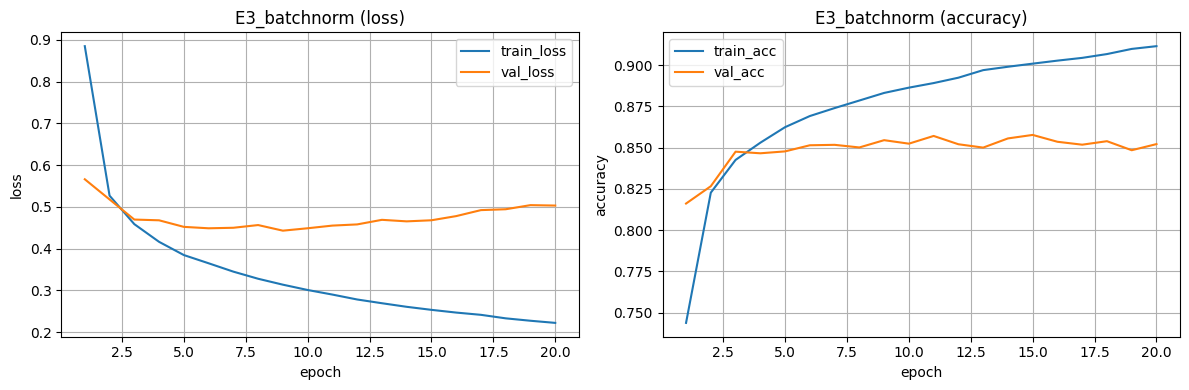

In [12]:
# E3 — BatchNorm: как E1, но с BatchNorm
set_seed(42)

e3_model = MLP(
    hidden_dims=HIDDEN_DIMS,
    num_classes=NUM_CLASSES,
    dropout_p=0.0,
    use_batchnorm=True,
).to(device)

optimizer_e3 = optim.Adam(e3_model.parameters(), lr=LR)

history_e3 = fit(
    model=e3_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e3,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    early_stopping=None,
)

best_val_acc_e3 = max(history_e3["val_acc"])
best_val_loss_e3 = min(history_e3["val_loss"])
epochs_trained_e3 = len(history_e3["train_loss"])

print("best val_acc:", best_val_acc_e3)
print("best val_loss:", best_val_loss_e3)

plot_history(history_e3, title="E3_batchnorm")

append_run_to_csv({
    "experiment_id": "E3",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": make_model_summary(HIDDEN_DIMS, ACTIVATION, 0.0, True),
    "optimizer": "Adam",
    "lr": LR,
    "momentum": 0,
    "weight_decay": WEIGHT_DECAY,
    "epochs_trained": epochs_trained_e3,
    "best_val_accuracy": best_val_acc_e3,
    "best_val_loss": best_val_loss_e3,
})

Эксперимент 3: EarlyStopping


Лучший из E2/E3 по val_accuracy: E3_batchnorm
epoch 01/50 | train loss=0.8852, acc=0.7438 | val loss=0.5662, acc=0.8161
epoch 02/50 | train loss=0.5268, acc=0.8227 | val loss=0.5178, acc=0.8266
epoch 03/50 | train loss=0.4586, acc=0.8425 | val loss=0.4696, acc=0.8475
epoch 04/50 | train loss=0.4162, acc=0.8530 | val loss=0.4678, acc=0.8466
epoch 05/50 | train loss=0.3845, acc=0.8624 | val loss=0.4521, acc=0.8477
epoch 06/50 | train loss=0.3648, acc=0.8691 | val loss=0.4486, acc=0.8514
epoch 07/50 | train loss=0.3447, acc=0.8740 | val loss=0.4499, acc=0.8517
epoch 08/50 | train loss=0.3277, acc=0.8785 | val loss=0.4564, acc=0.8501
epoch 09/50 | train loss=0.3135, acc=0.8831 | val loss=0.4429, acc=0.8545
epoch 10/50 | train loss=0.3007, acc=0.8863 | val loss=0.4487, acc=0.8524
epoch 11/50 | train loss=0.2898, acc=0.8891 | val loss=0.4551, acc=0.8571
epoch 12/50 | train loss=0.2780, acc=0.8924 | val loss=0.4579, acc=0.8520
epoch 13/50 | train loss=0.2690, acc=0.8970 | val loss=0.4689, ac

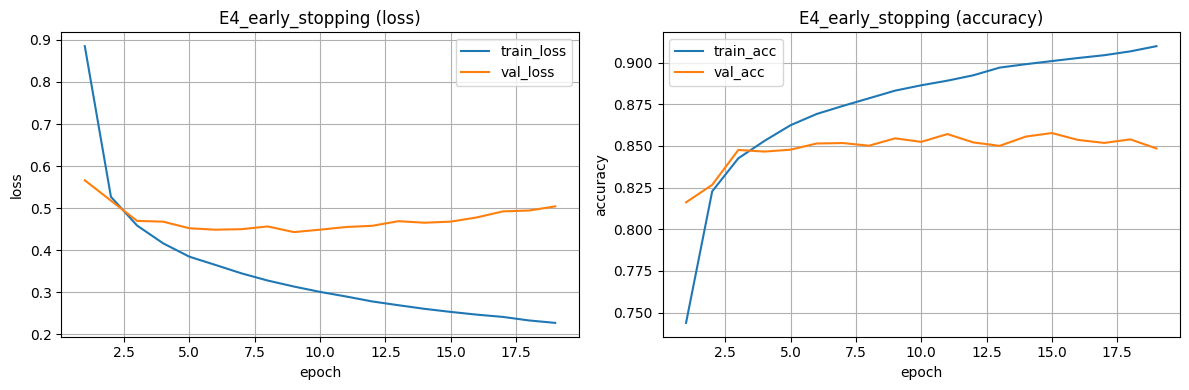

In [13]:
best_e2_val_acc = max(history_e2["val_acc"])
best_e3_val_acc = max(history_e3["val_acc"])

if best_e2_val_acc >= best_e3_val_acc:
    best_prev_name = "E2_dropout"
    best_config = {
        "hidden_dims": HIDDEN_DIMS,
        "num_classes": NUM_CLASSES,
        "activation": ACTIVATION,
        "dropout_p": 0.3,
        "use_batchnorm": False,
    }
else:
    best_prev_name = "E3_batchnorm"
    best_config = {
        "hidden_dims": HIDDEN_DIMS,
        "num_classes": NUM_CLASSES,
        "activation": ACTIVATION,
        "dropout_p": 0.0,
        "use_batchnorm": True,
    }

print("\nЛучший из E2/E3 по val_accuracy:", best_prev_name)


# E4 — лучший из E2/E3, но с EarlyStopping
set_seed(42)

e4_model = MLP(**best_config).to(device)
optimizer_e4 = optim.Adam(e4_model.parameters(), lr=LR)

early_stopping_e4 = EarlyStopping(patience=4, min_delta=0.0005)

history_e4 = fit(
    model=e4_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e4,
    criterion=criterion,
    device=device,
    epochs=50,   # можно дать больше, EarlyStopping остановит раньше
    early_stopping=early_stopping_e4,
)

best_val_acc_e4 = max(history_e4["val_acc"])
best_val_loss_e4 = min(history_e4["val_loss"])
epochs_trained_e4 = len(history_e4["train_loss"])

print("\nE4: early stopping")
print("best val_acc:", best_val_acc_e4)
print("best val_loss:", best_val_loss_e4)

plot_history(
    history_e4,
    title="E4_early_stopping",
    save_path="artifacts/figures/curves_best.png"
)

append_run_to_csv({
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": make_model_summary(
        best_config["hidden_dims"],
        best_config["activation"],
        best_config["dropout_p"],
        best_config["use_batchnorm"],
    ),
    "optimizer": "Adam",
    "lr": LR,
    "momentum": 0,
    "weight_decay": WEIGHT_DECAY,
    "epochs_trained": epochs_trained_e4,
    "best_val_accuracy": best_val_acc_e4,
    "best_val_loss": best_val_loss_e4,
})

# Сохраняем лучшую модель E4
torch.save(e4_model.state_dict(), "artifacts/best_model.pt")

In [14]:
best_config_to_save = {
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model": {
        "hidden_dims": list(best_config["hidden_dims"]),
        "num_classes": best_config["num_classes"],
        "activation": best_config["activation"],
        "dropout_p": best_config["dropout_p"],
        "use_batchnorm": best_config["use_batchnorm"],
    },
    "training": {
        "optimizer": "Adam",
        "lr": LR,
        "momentum": 0,
        "weight_decay": WEIGHT_DECAY,
        "epochs_trained": epochs_trained_e4,
        "early_stopping_patience": 4,
        "early_stopping_min_delta": 0.0005,
    }
}

with open("artifacts/best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config_to_save, f, ensure_ascii=False, indent=2)


TEST используем только один раз — в самом конце

In [15]:
test_loss, test_acc = evaluate(e4_model, test_loader, criterion, device)

print("\nFINAL TEST for E4")
print(f"test_loss = {test_loss:.4f}")
print(f"test_acc  = {test_acc:.4f}")


FINAL TEST for E4
test_loss = 0.4904
test_acc  = 0.8503


##### Выводы:
1. PyTorch-минимум для нейросети – это: Dataset/DataLoader, nn.Module, loss, optimizer, правильные режимы train/eval.
2. Переобучение видно по разрыву train/val и росту val loss при падении train loss.
3. Dropout, BatchNorm, EarlyStopping – это практичные базовые инструменты, которые часто дают выигрыш.
4. Активации и инициализация реально влияют на динамику обучения (поэтому важно понимать, что вы включаете в модель).

## Part B

In [16]:
O_EPOCHS_SHORT = 6   # для O1 и O2
O_EPOCHS_SGD = 12    # для O3, можно 10-15

LR_TOO_BIG = 1e-1
LR_TOO_SMALL = 1e-5

SGD_LR = 1e-2
SGD_MOMENTUM = 0.9
SGD_WEIGHT_DECAY = 1e-4

epoch 01/6 | train loss=1.1935, acc=0.6417 | val loss=0.8415, acc=0.7442
epoch 02/6 | train loss=0.8812, acc=0.7262 | val loss=0.7801, acc=0.7612
epoch 03/6 | train loss=0.8029, acc=0.7472 | val loss=0.7216, acc=0.7721
epoch 04/6 | train loss=0.7593, acc=0.7599 | val loss=0.7208, acc=0.7714
epoch 05/6 | train loss=0.7344, acc=0.7665 | val loss=0.7174, acc=0.7879
epoch 06/6 | train loss=0.7139, acc=0.7722 | val loss=0.7239, acc=0.7811

O1: Adam, LR too large
best val_acc: 0.7878707627118644
best val_loss: 0.7174372545069894


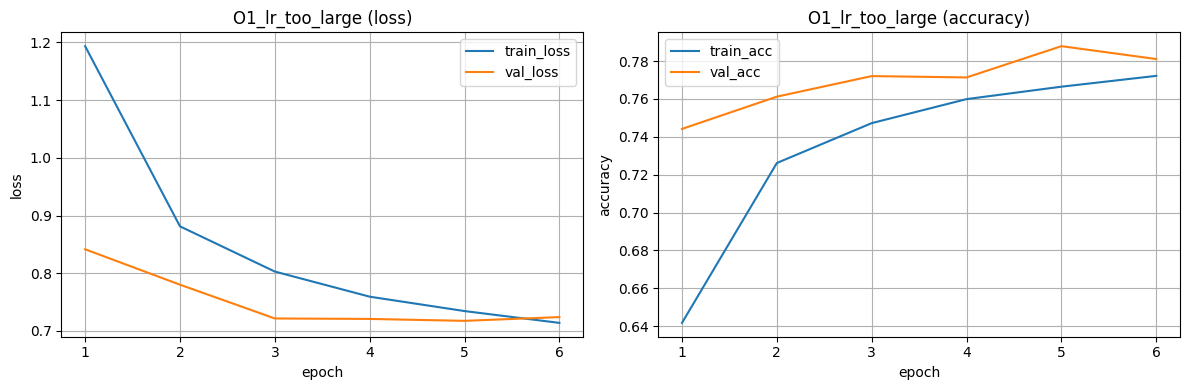

In [17]:
# O1 — LR слишком большой
set_seed(SEED)

o1_model = MLP(**best_config).to(device)

optimizer_o1 = optim.Adam(o1_model.parameters(), lr=LR_TOO_BIG)

history_o1 = fit(
    model=o1_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o1,
    criterion=criterion,
    device=device,
    epochs=O_EPOCHS_SHORT,
    early_stopping=None,
)

best_val_acc_o1 = max(history_o1["val_acc"])
best_val_loss_o1 = min(history_o1["val_loss"])
epochs_trained_o1 = len(history_o1["train_loss"])

print("\nO1: Adam, LR too large")
print("best val_acc:", best_val_acc_o1)
print("best val_loss:", best_val_loss_o1)

plot_history(history_o1, title="O1_lr_too_large")

append_run_to_csv({
    "experiment_id": "O1",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": make_model_summary(
        best_config["hidden_dims"],
        best_config["activation"],
        best_config["dropout_p"],
        best_config["use_batchnorm"],
    ),
    "optimizer": "Adam",
    "lr": LR_TOO_BIG,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": epochs_trained_o1,
    "best_val_accuracy": best_val_acc_o1,
    "best_val_loss": best_val_loss_o1,
})

epoch 01/6 | train loss=3.2802, acc=0.2490 | val loss=2.8342, acc=0.4370
epoch 02/6 | train loss=2.6035, acc=0.4980 | val loss=2.3592, acc=0.5581
epoch 03/6 | train loss=2.2144, acc=0.5810 | val loss=2.0260, acc=0.6186
epoch 04/6 | train loss=1.9200, acc=0.6276 | val loss=1.7733, acc=0.6526
epoch 05/6 | train loss=1.6870, acc=0.6590 | val loss=1.5650, acc=0.6756
epoch 06/6 | train loss=1.5042, acc=0.6799 | val loss=1.3983, acc=0.6976

O2: Adam, LR too small
best val_acc: 0.6975635593220338
best val_loss: 1.3982841914656472


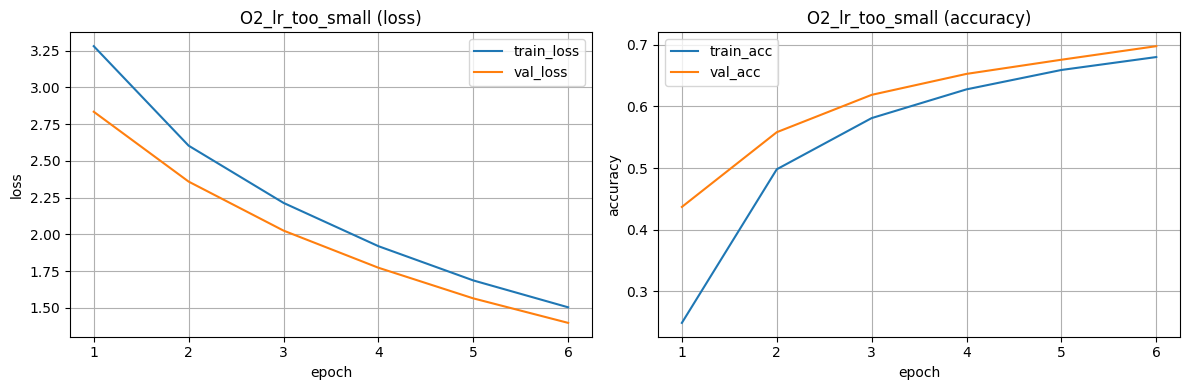

In [18]:
# O2 — LR слишком маленький
set_seed(SEED)

o2_model = MLP(**best_config).to(device)

optimizer_o2 = optim.Adam(o2_model.parameters(), lr=LR_TOO_SMALL)

history_o2 = fit(
    model=o2_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o2,
    criterion=criterion,
    device=device,
    epochs=O_EPOCHS_SHORT,
    early_stopping=None,
)

best_val_acc_o2 = max(history_o2["val_acc"])
best_val_loss_o2 = min(history_o2["val_loss"])
epochs_trained_o2 = len(history_o2["train_loss"])

print("\nO2: Adam, LR too small")
print("best val_acc:", best_val_acc_o2)
print("best val_loss:", best_val_loss_o2)

plot_history(history_o2, title="O2_lr_too_small")

append_run_to_csv({
    "experiment_id": "O2",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": make_model_summary(
        best_config["hidden_dims"],
        best_config["activation"],
        best_config["dropout_p"],
        best_config["use_batchnorm"],
    ),
    "optimizer": "Adam",
    "lr": LR_TOO_SMALL,
    "momentum": 0,
    "weight_decay": 0.0,
    "epochs_trained": epochs_trained_o2,
    "best_val_accuracy": best_val_acc_o2,
    "best_val_loss": best_val_loss_o2,
})

epoch 01/12 | train loss=0.9267, acc=0.7300 | val loss=0.5807, acc=0.8150
epoch 02/12 | train loss=0.5528, acc=0.8177 | val loss=0.5278, acc=0.8272
epoch 03/12 | train loss=0.4794, acc=0.8374 | val loss=0.4762, acc=0.8446
epoch 04/12 | train loss=0.4353, acc=0.8484 | val loss=0.4776, acc=0.8430
epoch 05/12 | train loss=0.4042, acc=0.8576 | val loss=0.4509, acc=0.8508
epoch 06/12 | train loss=0.3844, acc=0.8644 | val loss=0.4516, acc=0.8483
epoch 07/12 | train loss=0.3659, acc=0.8685 | val loss=0.4453, acc=0.8521
epoch 08/12 | train loss=0.3501, acc=0.8717 | val loss=0.4454, acc=0.8506
epoch 09/12 | train loss=0.3371, acc=0.8772 | val loss=0.4412, acc=0.8520
epoch 10/12 | train loss=0.3250, acc=0.8815 | val loss=0.4427, acc=0.8539
epoch 11/12 | train loss=0.3146, acc=0.8833 | val loss=0.4470, acc=0.8543
epoch 12/12 | train loss=0.3028, acc=0.8865 | val loss=0.4456, acc=0.8535

O3: SGD + momentum + weight decay
best val_acc: 0.854343220338983
best val_loss: 0.44116244157828854


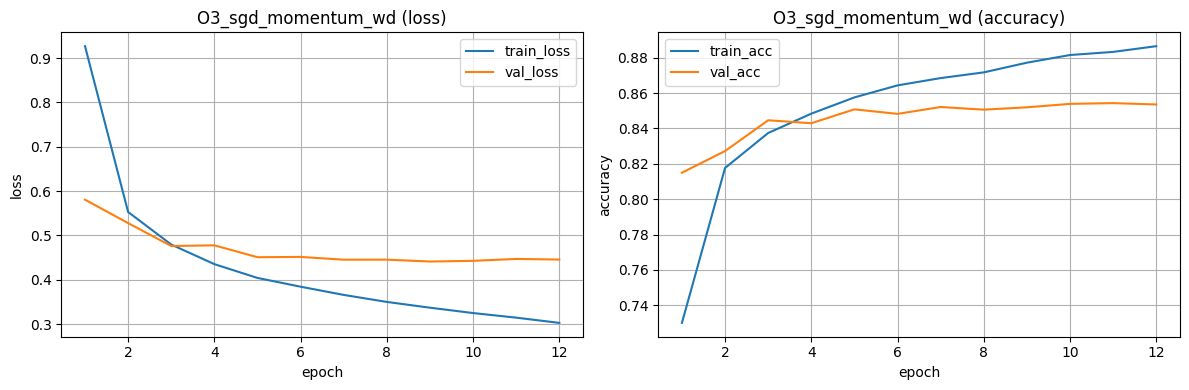

In [19]:
# O3 — SGD + momentum + weight decay
set_seed(SEED)

o3_model = MLP(**best_config).to(device)

optimizer_o3 = optim.SGD(
    o3_model.parameters(),
    lr=SGD_LR,
    momentum=SGD_MOMENTUM,
    weight_decay=SGD_WEIGHT_DECAY,
)

history_o3 = fit(
    model=o3_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o3,
    criterion=criterion,
    device=device,
    epochs=O_EPOCHS_SGD,
    early_stopping=None,
)

best_val_acc_o3 = max(history_o3["val_acc"])
best_val_loss_o3 = min(history_o3["val_loss"])
epochs_trained_o3 = len(history_o3["train_loss"])

print("\nO3: SGD + momentum + weight decay")
print("best val_acc:", best_val_acc_o3)
print("best val_loss:", best_val_loss_o3)

plot_history(history_o3, title="O3_sgd_momentum_wd")

append_run_to_csv({
    "experiment_id": "O3",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_summary": make_model_summary(
        best_config["hidden_dims"],
        best_config["activation"],
        best_config["dropout_p"],
        best_config["use_batchnorm"],
    ),
    "optimizer": "SGD",
    "lr": SGD_LR,
    "momentum": SGD_MOMENTUM,
    "weight_decay": SGD_WEIGHT_DECAY,
    "epochs_trained": epochs_trained_o3,
    "best_val_accuracy": best_val_acc_o3,
    "best_val_loss": best_val_loss_o3,
})

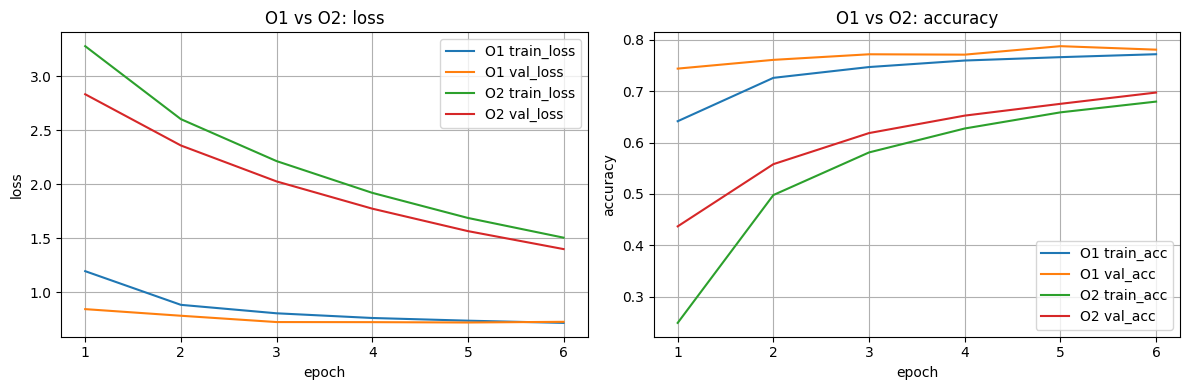

In [20]:
epochs_o1 = np.arange(1, len(history_o1["train_loss"]) + 1)
epochs_o2 = np.arange(1, len(history_o2["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss
axes[0].plot(epochs_o1, history_o1["train_loss"], label="O1 train_loss")
axes[0].plot(epochs_o1, history_o1["val_loss"], label="O1 val_loss")
axes[0].plot(epochs_o2, history_o2["train_loss"], label="O2 train_loss")
axes[0].plot(epochs_o2, history_o2["val_loss"], label="O2 val_loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("O1 vs O2: loss")
axes[0].legend()
axes[0].grid(True)

# accuracy
axes[1].plot(epochs_o1, history_o1["train_acc"], label="O1 train_acc")
axes[1].plot(epochs_o1, history_o1["val_acc"], label="O1 val_acc")
axes[1].plot(epochs_o2, history_o2["train_acc"], label="O2 train_acc")
axes[1].plot(epochs_o2, history_o2["val_acc"], label="O2 val_acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("O1 vs O2: accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", bbox_inches="tight")
plt.show()